In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

AAP848 - 4764428779

"Abastecimiento de combustible 90.26 galones, placa AAP848, fecha 10-06-26 no aparece en el sensor de combustible, ni en el sistema."

It only reported until 05-06-2026 3:23:26 UTC.

Chart of values: This part of the notebook is for troubleshooting and graphical analysis.

In [32]:
#raw_fuel_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export.xlsx - Sheet1.csv',sep=',',encoding='latin1')
raw_fuel_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\t_pesqueros\Export_aap848.xlsx') #excel
raw_fuel_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1783 entries, 0 to 1782
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1783 non-null   str  
 1   Message  1783 non-null   str  
 2   Status   1783 non-null   str  
dtypes: str(3)
memory usage: 41.9 KB


In [33]:
e0x=raw_fuel_data[raw_fuel_data['Status'].str.contains('3E0')]
row_number=e0x.shape[0]
#e0x.to_csv('/home/jlhb1984/py-projects/data/veepo/wcr728_.csv')

In [34]:
fs01_dec_value=[]
fs02_dec_value=[]
last_index_fs01=[]
last_index_fs02=[]
date_fs01_dec_value=[]
date_fs02_dec_value=[]
values_dates_fs01=pd.DataFrame()
values_dates_fs02=pd.DataFrame()

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    aux=e0x_aux.find('3E01')    
    if len(e0x_aux)>0:
        fs01=(e0x_aux[aux:aux+18])
        if len(fs01)>17:
            msb=fs01[10:12]
            lsb=fs01[8:10]
            measure=msb+lsb
            fs01_dec_value.append(int(measure,16))
            date_fs01_dec_value.append(e0x.iloc[i,0])            
            msb=fs01[28:30]
            lsb=fs01[26:28]
            fs01_dec_value.append(int(measure,16))
            date_fs01_dec_value.append(e0x.iloc[i,0]) 
            msb=fs01[46:48]
            lsb=fs01[44:46]
            fs01_dec_value.append(int(measure,16))
            date_fs01_dec_value.append(e0x.iloc[i,0])
            msb=fs01[46:48]
            lsb=fs01[44:46]
            fs01_dec_value.append(int(measure,16))
            date_fs01_dec_value.append(e0x.iloc[i,0])
            msb=fs01[64:66]
            lsb=fs01[62:64]
            last_index_fs01=i        
            
#print(i, raw_fuel_data.iloc[i,0] )

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    aux=e0x_aux.find('3E02')
    if len(e0x_aux)>0:
        fs02=e0x_aux[aux:aux+18]
        if len(fs02)>17:
            msb=fs02[10:12]
            lsb=fs02[8:10]
            measure=msb+lsb
            fs02_dec_value.append(int(measure,16))
            date_fs02_dec_value.append(e0x.iloc[i,0])            
            msb=fs02[28:30]
            lsb=fs02[26:28]
            fs02_dec_value.append(int(measure,16))
            date_fs02_dec_value.append(e0x.iloc[i,0]) 
            msb=fs02[46:48]
            lsb=fs02[44:46]
            fs02_dec_value.append(int(measure,16))
            date_fs02_dec_value.append(e0x.iloc[i,0])
            msb=fs02[46:48]
            lsb=fs02[44:46]
            fs02_dec_value.append(int(measure,16))
            date_fs02_dec_value.append(e0x.iloc[i,0])
            msb=fs02[64:66]
            lsb=fs02[62:64]
            last_index_fs02=i        
            
        #print(fs01_cad)   

fs01_count=len(fs01_dec_value)
fs02_count=len(fs02_dec_value)
values_dates_fs01['Value fs01']=fs01_dec_value
values_dates_fs01['Dates fs01']=date_fs01_dec_value
values_dates_fs02['Value fs02']=fs02_dec_value
values_dates_fs02['Dates fs02']=date_fs02_dec_value

#print('El Ncode en decimal es:')
print(fs01_dec_value,fs01_count)
print("Last fuel report fs01: ",e0x.iloc[last_index_fs01,0],"Last fuel report fs02: ",e0x.iloc[last_index_fs02,0])            


[1938, 1938, 1938, 1938, 1941, 1941, 1941, 1941, 1942, 1942, 1942, 1942, 1903, 1903, 1903, 1903, 1953, 1953, 1953, 1953, 1938, 1938, 1938, 1938, 1912, 1912, 1912, 1912, 1909, 1909, 1909, 1909, 1974, 1974, 1974, 1974, 2008, 2008, 2008, 2008, 2017, 2017, 2017, 2017, 2048, 2048, 2048, 2048, 2079, 2079, 2079, 2079, 2110, 2110, 2110, 2110, 2141, 2141, 2141, 2141, 2171, 2171, 2171, 2171, 2154, 2154, 2154, 2154, 2118, 2118, 2118, 2118, 2166, 2166, 2166, 2166, 2168, 2168, 2168, 2168, 2167, 2167, 2167, 2167, 2166, 2166, 2166, 2166, 2166, 2166, 2166, 2166, 165, 165, 165, 165, 198, 198, 198, 198, 173, 173, 173, 173, 167, 167, 167, 167, 141, 141, 141, 141, 141, 141, 141, 141, 135, 135, 135, 135, 130, 130, 130, 130, 118, 118, 118, 118, 117, 117, 117, 117, 108, 108, 108, 108, 99, 99, 99, 99, 97, 97, 97, 97, 93, 93, 93, 93, 95, 95, 95, 95, 98, 98, 98, 98, 97, 97, 97, 97, 100, 100, 100, 100, 100, 100, 100, 100, 101, 101, 101, 101, 99, 99, 99, 99, 99, 99, 99, 99, 90, 90, 90, 90, 95, 95, 95, 95, 97, 97,

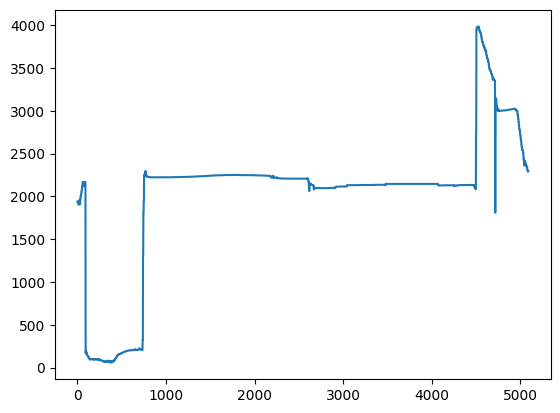

In [35]:
fs01_x_values=[]
fs02_x_values=[]

for i in range(0,fs01_count):
    fs01_x_values.append(i)
    
for i in range(0,fs02_count):
    fs02_x_values.append(i)

plt.plot(fs01_x_values,fs01_dec_value)
#plt.plot(fs02_x_values,fs02_dec_value)

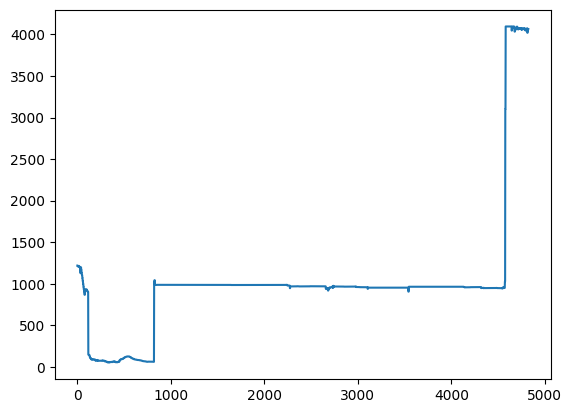

In [36]:
plt.plot(fs02_x_values,fs02_dec_value)
#plt.plot(fs02_x_values,fs02_dec_value)

In [37]:
int_value=int(input('Type the Ncode to look for: '))
for i in range(0,values_dates_fs01.shape[0]):
    if values_dates_fs01.iloc[i,0]>int_value:
        print(values_dates_fs01.loc[i])

Value fs01                       3948
Dates fs01    2026-06-04 16:01:31.544
Name: 4504, dtype: object
Value fs01                       3948
Dates fs01    2026-06-04 16:01:31.544
Name: 4505, dtype: object
Value fs01                       3948
Dates fs01    2026-06-04 16:01:31.544
Name: 4506, dtype: object
Value fs01                       3948
Dates fs01    2026-06-04 16:01:31.544
Name: 4507, dtype: object
Value fs01                       3976
Dates fs01    2026-06-04 16:04:11.525
Name: 4508, dtype: object
Value fs01                       3976
Dates fs01    2026-06-04 16:04:11.525
Name: 4509, dtype: object
Value fs01                       3976
Dates fs01    2026-06-04 16:04:11.525
Name: 4510, dtype: object
Value fs01                       3976
Dates fs01    2026-06-04 16:04:11.525
Name: 4511, dtype: object
Value fs01                       3977
Dates fs01    2026-06-04 16:06:51.523
Name: 4512, dtype: object
Value fs01                       3977
Dates fs01    2026-06-04 16:06:51.523
Name: 

In [38]:
for i in range(0,values_dates_fs02.shape[0]):
    if values_dates_fs02.iloc[i,0]>int_value:
        print(values_dates_fs01.loc[i])

Value fs01                       3778
Dates fs01    2026-06-04 16:52:11.858
Name: 4580, dtype: object
Value fs01                       3778
Dates fs01    2026-06-04 16:52:11.858
Name: 4581, dtype: object
Value fs01                       3778
Dates fs01    2026-06-04 16:52:11.858
Name: 4582, dtype: object
Value fs01                       3778
Dates fs01    2026-06-04 16:52:11.858
Name: 4583, dtype: object
Value fs01                       3756
Dates fs01    2026-06-04 16:54:51.972
Name: 4584, dtype: object
Value fs01                       3756
Dates fs01    2026-06-04 16:54:51.972
Name: 4585, dtype: object
Value fs01                       3756
Dates fs01    2026-06-04 16:54:51.972
Name: 4586, dtype: object
Value fs01                       3756
Dates fs01    2026-06-04 16:54:51.972
Name: 4587, dtype: object
Value fs01                       3758
Dates fs01    2026-06-04 16:57:31.856
Name: 4588, dtype: object
Value fs01                       3758
Dates fs01    2026-06-04 16:57:31.856
Name: 